In [9]:
import torch.nn as nn
import torch.optim as optim

# 2.1. Definição da Arquitetura MLP com Função de Ativação Personalizável
class FlexibleMLP(nn.Module):
    def __init__(self, activation_fn=nn.ReLU()):
        super(FlexibleMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(4, 32),  # Camada de Entrada
            activation_fn,     # Ativação configurável
            nn.Linear(32, 16), # Camada Oculta
            activation_fn,     # Ativação configurável
            nn.Linear(16, 3)   # Camada de Saída (3 classes no Iris)
        )

    def forward(self, x):
        return self.layers(x)

# Função auxiliar para treinar e avaliar o modelo
def train_and_evaluate(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=100):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        _, train_pred = torch.max(outputs, 1)
        train_acc = (train_pred == y_train).sum().item() / y_train.size(0)

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            t_loss = criterion(test_outputs, y_test)
            _, test_pred = torch.max(test_outputs, 1)
            test_acc = (test_pred == y_test).sum().item() / y_test.size(0)

        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_loss'].append(t_loss.item())
        history['test_acc'].append(test_acc)

    return history


### Testando Modelos com diferentes Funções de Ativação

In [10]:
# 2.2. Teste com ReLU
print("\n--- Testando com ReLU ---")
model_relu = FlexibleMLP(activation_fn=nn.ReLU())
optimizer_relu = optim.Adam(model_relu.parameters(), lr=0.01)
history_relu = train_and_evaluate(model_relu, criterion, optimizer_relu, X_train, y_train, X_test, y_test)
print(f"Última Acurácia de Treino (ReLU): {history_relu['train_acc'][-1]:.4f}")
print(f"Última Acurácia de Validação (ReLU): {history_relu['test_acc'][-1]:.4f}")

# 2.3. Teste com Tanh
print("\n--- Testando com Tanh ---")
model_tanh = FlexibleMLP(activation_fn=nn.Tanh())
optimizer_tanh = optim.Adam(model_tanh.parameters(), lr=0.01)
history_tanh = train_and_evaluate(model_tanh, criterion, optimizer_tanh, X_train, y_train, X_test, y_test)
print(f"Última Acurácia de Treino (Tanh): {history_tanh['train_acc'][-1]:.4f}")
print(f"Última Acurácia de Validação (Tanh): {history_tanh['test_acc'][-1]:.4f}")

# 2.4. Teste com Sigmoid
print("\n--- Testando com Sigmoid ---")
model_sigmoid = FlexibleMLP(activation_fn=nn.Sigmoid())
optimizer_sigmoid = optim.Adam(model_sigmoid.parameters(), lr=0.01)
history_sigmoid = train_and_evaluate(model_sigmoid, criterion, optimizer_sigmoid, X_train, y_train, X_test, y_test)
print(f"Última Acurácia de Treino (Sigmoid): {history_sigmoid['train_acc'][-1]:.4f}")
print(f"Última Acurácia de Validação (Sigmoid): {history_sigmoid['test_acc'][-1]:.4f}")



--- Testando com ReLU ---
Última Acurácia de Treino (ReLU): 0.9833
Última Acurácia de Validação (ReLU): 1.0000

--- Testando com Tanh ---
Última Acurácia de Treino (Tanh): 0.9833
Última Acurácia de Validação (Tanh): 1.0000

--- Testando com Sigmoid ---
Última Acurácia de Treino (Sigmoid): 0.9667
Última Acurácia de Validação (Sigmoid): 1.0000


### Visualização Comparativa das Curvas de Treinamento

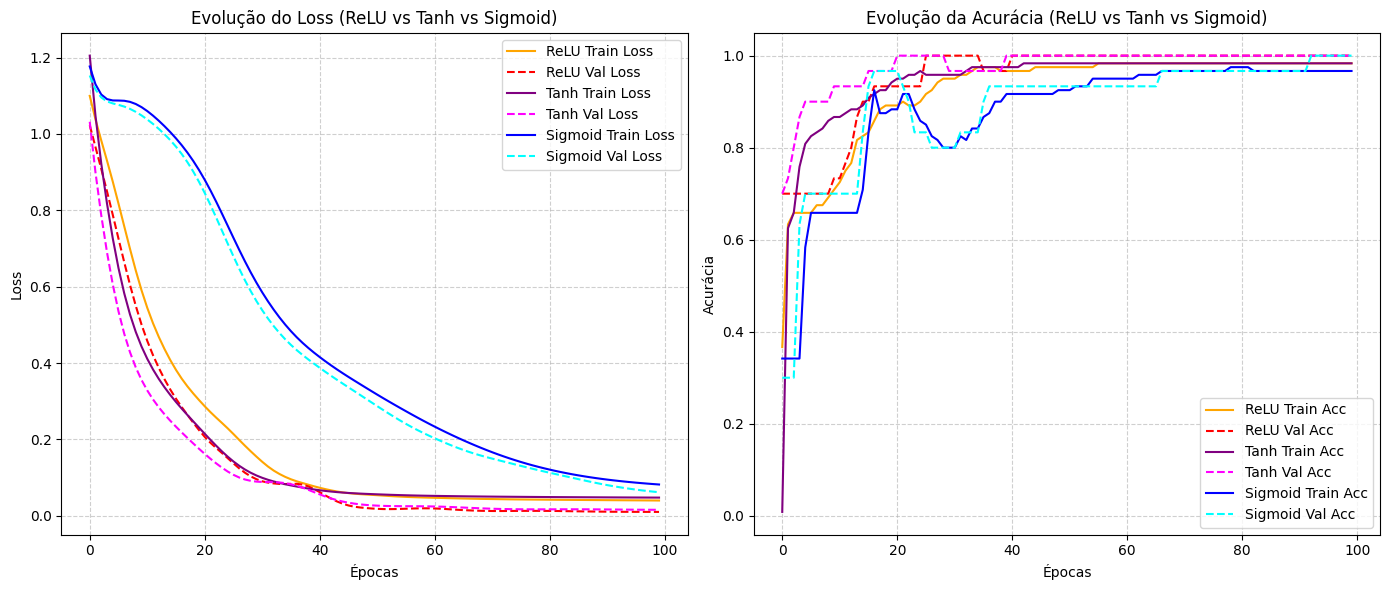

In [11]:
# 4.1. Visualização das Curvas de Perda (Loss)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_relu['train_loss'], label='ReLU Train Loss', color='orange')
plt.plot(history_relu['test_loss'], label='ReLU Val Loss', color='red', linestyle='--')
plt.plot(history_tanh['train_loss'], label='Tanh Train Loss', color='purple')
plt.plot(history_tanh['test_loss'], label='Tanh Val Loss', color='magenta', linestyle='--')
plt.plot(history_sigmoid['train_loss'], label='Sigmoid Train Loss', color='blue')
plt.plot(history_sigmoid['test_loss'], label='Sigmoid Val Loss', color='cyan', linestyle='--')
plt.title('Evolução do Loss (ReLU vs Tanh vs Sigmoid)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 4.2. Visualização das Curvas de Acurácia (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_relu['train_acc'], label='ReLU Train Acc', color='orange')
plt.plot(history_relu['test_acc'], label='ReLU Val Acc', color='red', linestyle='--')
plt.plot(history_tanh['train_acc'], label='Tanh Train Acc', color='purple')
plt.plot(history_tanh['test_acc'], label='Tanh Val Acc', color='magenta', linestyle='--')
plt.plot(history_sigmoid['train_acc'], label='Sigmoid Train Acc', color='blue')
plt.plot(history_sigmoid['test_acc'], label='Sigmoid Val Acc', color='cyan', linestyle='--')
plt.title('Evolução da Acurácia (ReLU vs Tanh vs Sigmoid)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparação dos Dados (Iris Dataset)
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Converter para Tensores do PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

In [13]:
import torch.nn as nn
import torch.optim as optim

# 2. Definição da Arquitetura MLP para Iris (4 entradas -> 3 saídas)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(4, 32),  # Camada de Entrada (tamanho médio)
            nn.ReLU(),         # Ativação
            nn.Linear(32, 16), # Camada Oculta (tamanho médio)
            nn.ReLU(),         # Ativação
            nn.Linear(16, 3)   # Camada de Saída (3 classes no Iris)
        )

    def forward(self, x):
        return self.layers(x)

model = MLP()
criterion = nn.CrossEntropyLoss() # Define criterion here
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)


In [14]:
# 3. Loop de Treinamento Atualizado com Train Acc
epochs = 100
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    # Calculando métricas de Treino
    _, train_pred = torch.max(outputs, 1)
    train_acc = (train_pred == y_train).sum().item() / y_train.size(0)

    # Avaliação (Validação)
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        t_loss = criterion(test_outputs, y_test)
        _, test_pred = torch.max(test_outputs, 1)
        test_acc = (test_pred == y_test).sum().item() / y_test.size(0)

    history['train_loss'].append(loss.item())
    history['train_acc'].append(train_acc)
    history['test_loss'].append(t_loss.item())
    history['test_acc'].append(test_acc)

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/100] | Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} | Val Loss: {t_loss.item():.4f} | Val Acc: {test_acc:.4f}')

Epoch [20/100] | Train Loss: 0.3277 | Train Acc: 0.9500 | Val Loss: 0.2424 | Val Acc: 1.0000
Epoch [40/100] | Train Loss: 0.0520 | Train Acc: 0.9833 | Val Loss: 0.0193 | Val Acc: 1.0000
Epoch [60/100] | Train Loss: 0.0446 | Train Acc: 0.9833 | Val Loss: 0.0118 | Val Acc: 1.0000
Epoch [80/100] | Train Loss: 0.0407 | Train Acc: 0.9833 | Val Loss: 0.0095 | Val Acc: 1.0000
Epoch [100/100] | Train Loss: 0.0364 | Train Acc: 0.9833 | Val Loss: 0.0092 | Val Acc: 1.0000


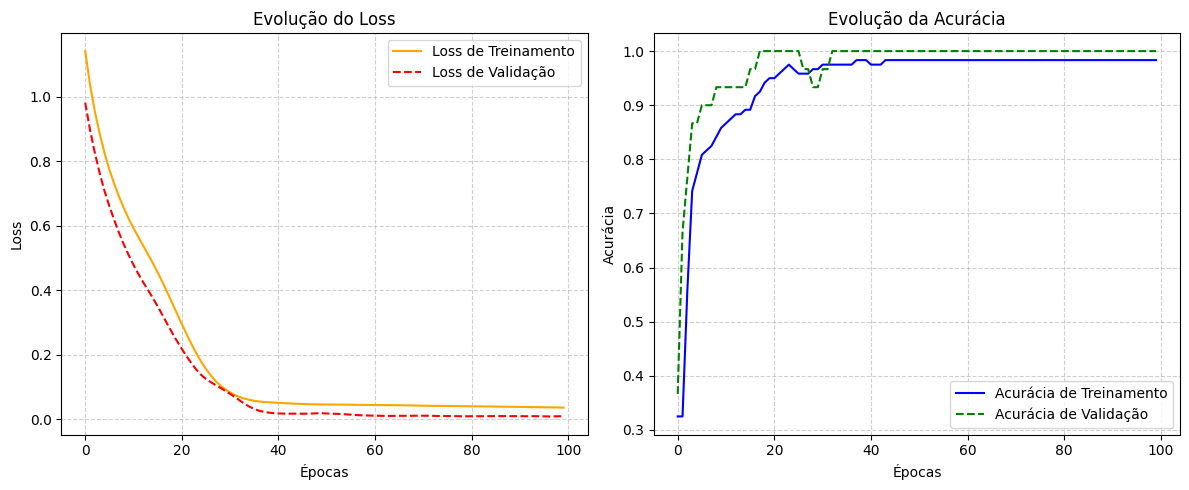

In [15]:
# 4. Visualização das Curvas (Treino e Validação)
plt.figure(figsize=(12, 5))

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Loss de Treinamento', color='orange')
plt.plot(history['test_loss'], label='Loss de Validação', color='red', linestyle='--')
plt.title('Evolução do Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Acurácia (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Acurácia de Treinamento', color='blue')
plt.plot(history['test_acc'], label='Acurácia de Validação', color='green', linestyle='--')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Detalhes das Camadas da MLP

Para o dataset Iris, uma rede menor é mais eficiente. Aqui está a estrutura detalhada:

1.  **Camada de Entrada (`nn.Linear(4, 16)`):**
    *   **Entrada:** 4 neurônios (comprimento/largura da sépala e pétala).
    *   **Saída:** 16 neurônios (espaço latente inicial).
2.  **Função de Ativação (`nn.ReLU`):**
    *   Introduz não-linearidade, permitindo que a rede aprenda padrões complexos.
3.  **Camada Oculta (`nn.Linear(16, 8)`):**
    *   **Entrada:** 16 neurônios.
    *   **Saída:** 8 neurônios (refinamento das características extraídas).
4.  **Camada de Saída (`nn.Linear(8, 3)`):**
    *   **Entrada:** 8 neurônios.
    *   **Saída:** 3 neurônios (um para cada classe: *Setosa*, *Versicolor*, *Virginica*).

In [16]:
import torch.nn as nn
import torch.optim as optim

# 2. Definição da Arquitetura MLP Reduzida
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(4, 64), # Camada de Entrada (aumentada para 64)
            nn.ReLU(),       # Ativação
            nn.Linear(64, 32), # Camada Oculta (aumentada para 32)
            nn.ReLU(),       # Ativação
            nn.Linear(32, 3)   # Camada de Saída (Logits)
        )

    def forward(self, x):
        return self.layers(x)

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)
